In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
import plotly.express as px
from mlp import MLP
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics._classification import confusion_matrix


In [2]:
layerSizes=[10] #don't count the output layer
activationFunction = "tanh"
lr = 0.001 # learning rate
useBias = True

Reading the data

In [3]:
data=pd.read_csv("penguins.csv")

In [4]:
data['Species'].value_counts()

Species
Adelie       50
Chinstrap    50
Gentoo       50
Name: count, dtype: int64

In [5]:
data.notna().sum().sum() # There's 8 values missing , we will impute them by the column mean

np.int64(892)

In [6]:
data.fillna(data.mean(numeric_only=True),inplace=True)

In [7]:
le=LabelEncoder()
data['OriginLocation']=le.fit_transform(data['OriginLocation'])
data['Species']=le.fit_transform(data['Species'])

In [8]:
numeric_cols = data.columns.drop(['OriginLocation','Species'])
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

First 30 samples of every species is taken as training data and the rest is for testing

In [9]:
trainingData=pd.concat((data[data['Species']==0][:30],data[data['Species']==1][:30],data[data['Species']==2][:30]))
testData = data.drop(trainingData.index)

Shuffle the data and reset its index

In [10]:
trainingData=trainingData.sample(frac=1).reset_index(drop=True)
testData=testData.sample(frac=1).reset_index(drop=True)

In [11]:
xTrain,yTrain=trainingData[trainingData.columns.drop('Species')],trainingData['Species']
xTest,yTest=testData[testData.columns.drop('Species')],testData['Species']

In [12]:
mlp = MLP(5,layerSizes,5)
mlp.lr = lr
if activationFunction == "tanh":
    mlp.UseTanh()
if useBias:
    mlp.UseBias()
mlp.Init()

In [13]:
acc = 0
accurecies = []
epochs = 30
for epoch in range(epochs):
    acc = mlp.fit(xTrain, yTrain)
    accurecies.append(acc / len(xTrain))

In [14]:
fig = px.line(accurecies)
fig.update_layout(
    xaxis_title = "Epoch",
    yaxis_title = "Accuracy"
)
fig.show()

In [15]:
acc=0

In [16]:
yPredict = mlp.predict(xTest)
for i in range(len(yPredict)):
    acc += 1 if (yPredict[i] == yTest[i]) else 0


In [17]:
acc / len(yTest)

0.95

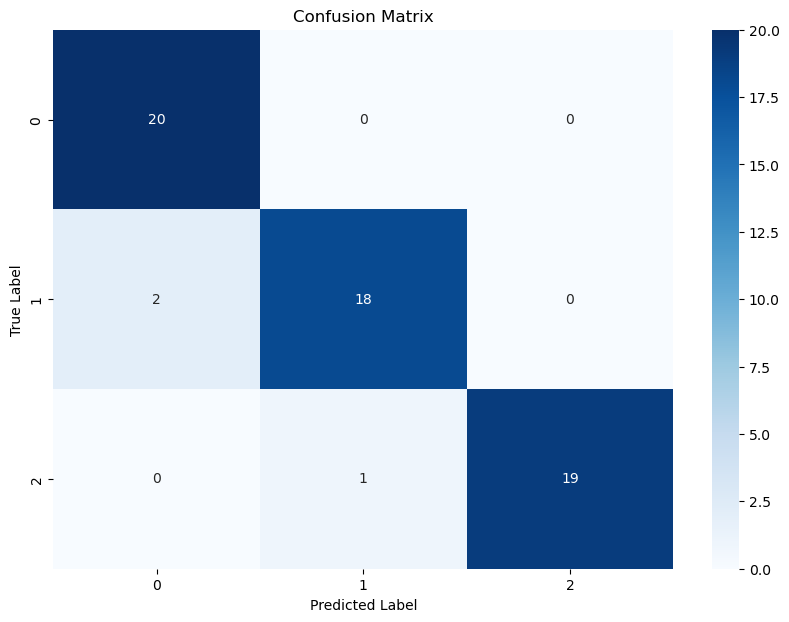

In [18]:
cm = confusion_matrix(yTest, yPredict)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
fig.show()